# Seamless Interaction — Gaze Analysis on 100 Annotated Pairs

Built for data downloaded via `download_annotated_interactions.py`.

**Expected directory structure:**
```
annotated_interactions/
├── V00_S1288_I00000099/
│   ├── interaction/
│   │   ├── interaction_metadata.json
│   │   ├── session_relationship.json
│   │   ├── participants_metadata.json
│   │   └── filelist_entries.json
│   ├── participant_a_P0071/
│   │   ├── 3P-IS_....json
│   │   ├── 3P-V_....json
│   │   └── vad_....jsonl
│   └── participant_b_P1119/
│       └── ...
└── ... (99 more)
```

**Tasks:**
1. **Visual Correlational / Distance Analysis** — gaze annotation positions, pairwise distances, per-dimension correlation
2. **Synchrony via Cosine Distance** — frame-level cosine distance, cross-lagged synchrony, within vs cross-session heatmap

## 0. Imports

In [1]:
import json
import re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
from scipy.signal import correlate
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1. Configure Path

In [2]:
# ── USER CONFIG ───────────────────────────────────────────────────────────────
ANNOTATED_ROOT = Path("Datasets/sli_data/annotated_interactions")   # <-- update if stored elsewhere
FPS            = 30.0                              # gaze encodings are at 30 Hz
GAZE_KEY       = "movement:gaze_encodings"         # key inside .npz files
# ─────────────────────────────────────────────────────────────────────────────

interaction_dirs = sorted([d for d in ANNOTATED_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(interaction_dirs)} interaction directories")
for d in interaction_dirs[:5]:
    print(f"  {d.name}")
if len(interaction_dirs) > 5:
    print(f"  ... and {len(interaction_dirs)-5} more")

Found 100 interaction directories
  V00_S1132_I00000333
  V00_S1132_I00000335
  V00_S1132_I00000336
  V00_S1132_I00000337
  V00_S1132_I00000352
  ... and 95 more


## 2. Inspect One Interaction
Check what files are present before building the full catalog.

In [3]:
def show_interaction_structure(idir: Path):
    """Print the file tree for one interaction directory."""
    print(f"\n{idir.name}/")
    for sub in sorted(idir.rglob('*')):
        depth  = len(sub.relative_to(idir).parts)
        indent = '  ' * depth
        print(f"{indent}{sub.name}")

show_interaction_structure(interaction_dirs[0])


V00_S1132_I00000333/
  interaction
    filelist_entries.json
    interaction_metadata.json
    participants_metadata.json
    session_relationship.json
  participant_a_P0737
    3P-IS_V00_S1132_I00000333_P0737.json
    3P-R_V00_S1132_I00000333_P0737.json
    3P-V_V00_S1132_I00000333_P0737.json
    V00_S1132_I00000333_P0737.npy
    V00_S1132_I00000333_P0737.wav
    vad_V00_S1132_I00000333_P0737.jsonl
  participant_b_P1093
    3P-IS_V00_S1132_I00000333_P1093.json
    3P-R_V00_S1132_I00000333_P1093.json
    3P-V_V00_S1132_I00000333_P1093.json
    V00_S1132_I00000333_P1093.npy
    V00_S1132_I00000333_P1093.wav
    vad_V00_S1132_I00000333_P1093.jsonl


## 3. Load Gaze Data + Metadata

Gaze encodings are stored as individual `.npy` files (one per participant),
downloaded by `download_gaze_encodings.py` into each `participant_a_*/` folder.

The loader checks for files in this priority order:
1. `{file_id}.npy` — individual gaze file from `download_gaze_encodings.py` ✅
2. `*.npz` — packed archive (fallback for earlier downloads)
3. `None` — V03 vendor or missing; falls back to annotation-only analysis

In [4]:
def find_participant_dirs(idir: Path) -> tuple[Path | None, Path | None]:
    """Return (participant_a_dir, participant_b_dir) for an interaction folder."""
    dirs = sorted([d for d in idir.iterdir()
                   if d.is_dir() and d.name.startswith('participant_')])
    a = next((d for d in dirs if d.name.startswith('participant_a')), None)
    b = next((d for d in dirs if d.name.startswith('participant_b')), None)
    return a, b


def load_gaze(pdir: Path) -> np.ndarray | None:
    """
    Load gaze encodings from a participant directory.
    Priority:
      1. {file_id}.npy  — individual file from download_gaze_encodings.py
      2. *.npz          — packed archive (fallback)
      3. None           — no gaze data available (V03 vendor or not downloaded)
    """
    # Priority 1: individual .npy file (shape: T x D)
    npy_files = list(pdir.glob('*.npy'))
    if npy_files:
        arr = np.load(npy_files[0])
        # Ensure 2D: some files may be saved as 1D or with extra dims
        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)
        return arr.astype(np.float32)

    # Priority 2: .npz packed archive
    npz_files = list(pdir.glob('*.npz'))
    if npz_files:
        data = np.load(npz_files[0], allow_pickle=True)
        if GAZE_KEY in data.files:
            return data[GAZE_KEY].astype(np.float32)
        for k in data.files:
            if 'gaze' in k.lower():
                return data[k].astype(np.float32)

    # Priority 3: no gaze data
    return None


def load_3pv_annotations(pdir: Path) -> list:
    """Load 3P-V visual behavior annotations (JSONL format, one object per line)."""
    vb_files = list(pdir.glob('3P-V_*.json*'))
    if not vb_files:
        return []
    annotations = []
    with open(vb_files[0], 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    annotations.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return annotations


def load_3pis_annotations(pdir: Path) -> list:
    """Load 3P-IS internal state annotations (JSONL format)."""
    is_files = list(pdir.glob('3P-IS_*.json*'))
    if not is_files:
        return []
    annotations = []
    with open(is_files[0], 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    annotations.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return annotations


def load_interaction_metadata(idir: Path) -> dict:
    """Load all metadata JSONs from the interaction/ subfolder."""
    meta = {}
    meta_dir = idir / 'interaction'
    for fname in ['interaction_metadata.json', 'session_relationship.json',
                  'participants_metadata.json', 'filelist_entries.json']:
        fpath = meta_dir / fname
        if fpath.exists():
            with open(fpath) as f:
                meta[fname.replace('.json', '')] = json.load(f)
    return meta


def extract_pid(pdir: Path) -> str:
    """Extract participant ID from directory name, e.g. participant_a_P0071 -> P0071."""
    return pdir.name.split('_')[-1]


# ── Build catalog ─────────────────────────────────────────────────────────────
records    = []
gaze_cache = {}   # interaction_id -> {'a': np.ndarray, 'b': np.ndarray}
meta_cache = {}   # interaction_id -> metadata dict
annot_cache = {}  # interaction_id -> {'a': [...], 'b': [...]}

no_gaze_count = 0

for idir in tqdm(interaction_dirs, desc='Loading interactions'):
    iid  = idir.name
    adir, bdir = find_participant_dirs(idir)
    if adir is None or bdir is None:
        continue

    pid_a = extract_pid(adir)
    pid_b = extract_pid(bdir)

    gaze_a = load_gaze(adir)
    gaze_b = load_gaze(bdir)
    annot_a = load_3pv_annotations(adir)
    annot_b = load_3pv_annotations(bdir)
    is_a   = load_3pis_annotations(adir)
    is_b   = load_3pis_annotations(bdir)
    meta   = load_interaction_metadata(idir)

    has_gaze = gaze_a is not None and gaze_b is not None
    has_gaze_partial = (gaze_a is not None) != (gaze_b is not None)  # only one has gaze
    if not has_gaze:
        no_gaze_count += 1

    # Parse interaction ID parts
    parts = iid.split('_')
    vendor  = parts[0][1:]
    session = parts[1][1:]
    prompt  = parts[2][1:]

    # Extract relationship type from metadata
    rel_type = 'unknown'
    if 'session_relationship' in meta:
        rel = meta['session_relationship']
        rel_type = rel.get('relationship_type', rel.get('detail', 'unknown'))

    # IPC codes
    ipc_a = ipc_b = ''
    if 'interaction_metadata' in meta:
        ipc_a = meta['interaction_metadata'].get('ipc_a', '')
        ipc_b = meta['interaction_metadata'].get('ipc_b', '')

    gaze_cache[iid]  = {'a': gaze_a, 'b': gaze_b}
    meta_cache[iid]  = meta
    annot_cache[iid] = {'a': annot_a, 'b': annot_b, 'is_a': is_a, 'is_b': is_b}

    rec = {
        'interaction_id': iid,
        'vendor': vendor, 'session': session, 'prompt': prompt,
        'pid_a': pid_a, 'pid_b': pid_b,
        'has_gaze': has_gaze,
        'n_frames_a': gaze_a.shape[0] if gaze_a is not None else 0,
        'n_frames_b': gaze_b.shape[0] if gaze_b is not None else 0,
        'gaze_dim':   gaze_a.shape[1] if gaze_a is not None else 0,
        'duration_s': round(gaze_a.shape[0] / FPS, 1) if gaze_a is not None else 0,
        'n_annot_a':  len(annot_a), 'n_annot_b': len(annot_b),
        'relationship': rel_type,
        'ipc_a': ipc_a, 'ipc_b': ipc_b,
    }
    records.append(rec)

catalog = pd.DataFrame(records)
n_full    = catalog['has_gaze'].sum()
n_none    = (catalog['n_frames_a'] == 0) & (catalog['n_frames_b'] == 0)
n_partial = len(catalog) - n_full - n_none.sum()
print(f"\nLoaded {len(catalog)} interactions")
print(f"  Both participants have gaze : {n_full}  (ready for Tasks 1 & 2)")
print(f"  One participant has gaze    : {n_partial}  (partial — excluded from dyadic analysis)")
print(f"  No gaze data (V03 vendor)   : {n_none.sum()}  (annotation-only)")
print(f"  Avg duration (gaze pairs)   : {catalog[catalog['has_gaze']]['duration_s'].mean():.1f}s")
print(f"  Gaze encoding dim           : {catalog['gaze_dim'].max()}")
print()
catalog.head()

Loading interactions:   0%|          | 0/100 [00:00<?, ?it/s]


Loaded 100 interactions
  Both participants have gaze : 54  (ready for Tasks 1 & 2)
  One participant has gaze    : 0  (partial — excluded from dyadic analysis)
  No gaze data (V03 vendor)   : 46  (annotation-only)
  Avg duration (gaze pairs)   : 292.7s
  Gaze encoding dim           : 2



,interaction_id,vendor,session,prompt,pid_a,pid_b,has_gaze,n_frames_a,n_frames_b,gaze_dim,duration_s,n_annot_a,n_annot_b,relationship,ipc_a,ipc_b
0,V00_S1132_I00000333,00,1132,00000333,P0737,P1093,True,7860,7860,2,262.0,3,4,unknown,ANCP,
1,V00_S1132_I00000335,00,1132,00000335,P0737,P1093,True,8700,8700,2,290.0,2,3,unknown,APCM,
2,V00_S1132_I00000336,00,1132,00000336,P0737,P1093,True,10620,10620,2,354.0,3,3,unknown,AMCP,
3,V00_S1132_I00000337,00,1132,00000337,P0737,P1093,True,3660,3660,2,122.0,1,2,unknown,APCM,
4,V00_S1132_I00000352,00,1132,00000352,P0737,P1093,True,6120,6120,2,204.0,4,3,unknown,AMCN,


## 4. Dataset Overview

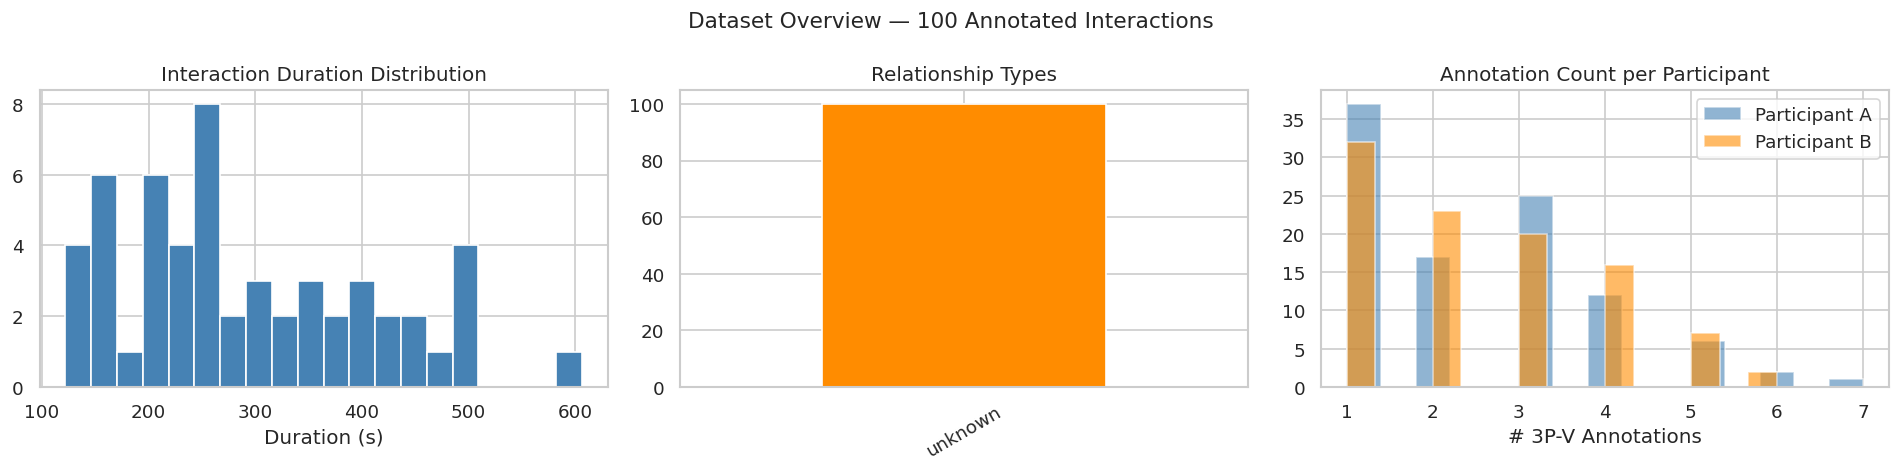

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Duration distribution
catalog[catalog['has_gaze']]['duration_s'].hist(
    ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Duration (s)')
axes[0].set_title('Interaction Duration Distribution')

# Relationship type breakdown
rel_counts = catalog['relationship'].value_counts()
rel_counts.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Relationship Types')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Annotation count distribution
catalog['n_annot_a'].hist(ax=axes[2], bins=15, alpha=0.6,
                           color='steelblue', label='Participant A', edgecolor='white')
catalog['n_annot_b'].hist(ax=axes[2], bins=15, alpha=0.6,
                           color='darkorange', label='Participant B', edgecolor='white')
axes[2].set_xlabel('# 3P-V Annotations')
axes[2].set_title('Annotation Count per Participant')
axes[2].legend()

fig.suptitle('Dataset Overview — 100 Annotated Interactions', fontsize=13)
plt.tight_layout()
plt.show()

---
## TASK 1 — Visual Correlational / Distance Analysis

### 5a. Per-Participant Gaze Trajectory (PCA) — Sample of 6 Interactions

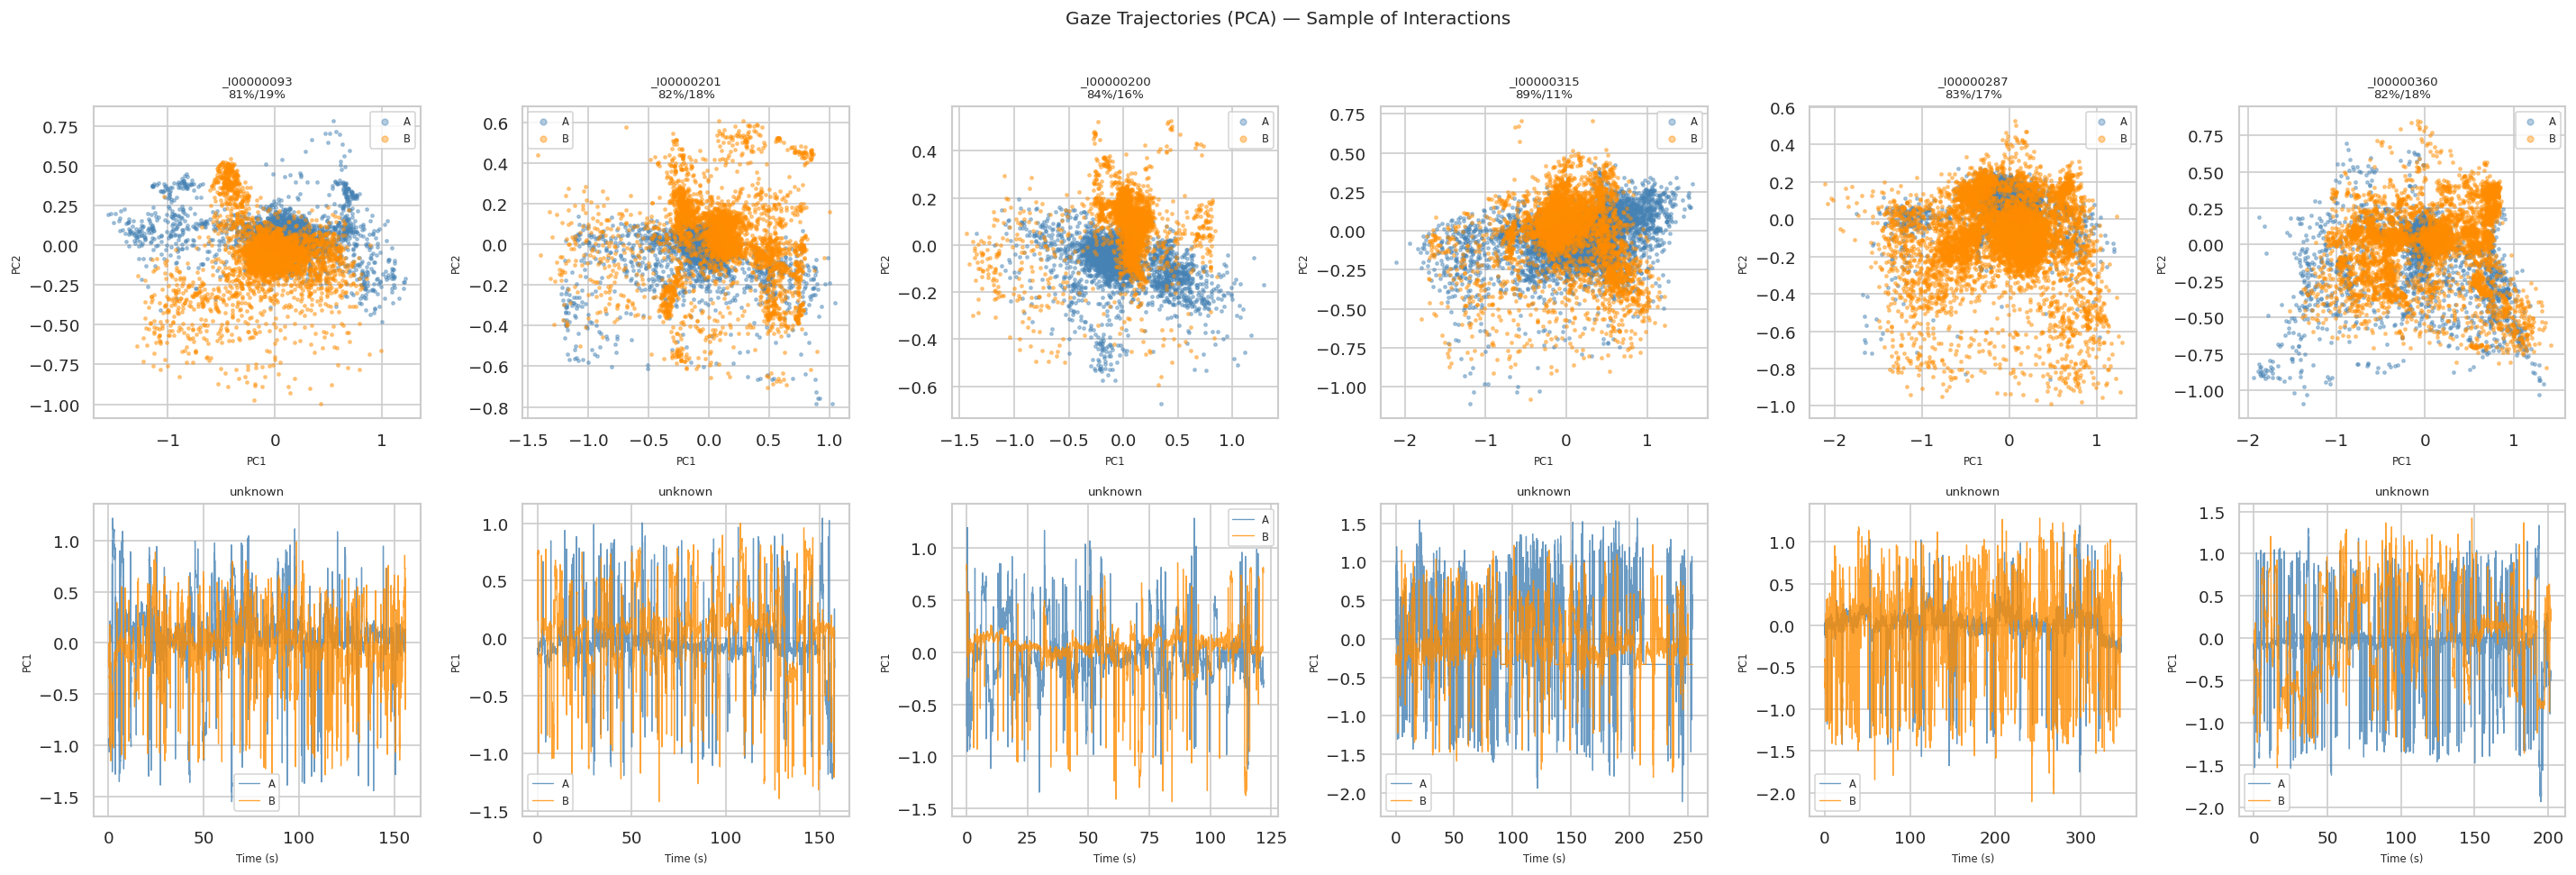

In [6]:
gaze_catalog = catalog[catalog['has_gaze']].reset_index(drop=True)

if len(gaze_catalog) == 0:
    print("No .npz gaze files found.")
    print("The download script fetched audio + annotations only.")
    print("See Section 5c for annotation-based gaze analysis.")
else:
    sample = gaze_catalog.sample(min(6, len(gaze_catalog)), random_state=42)
    n = len(sample)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for col, row in enumerate(sample.itertuples()):
        iid  = row.interaction_id
        ga   = gaze_cache[iid]['a']
        gb   = gaze_cache[iid]['b']
        T    = min(len(ga), len(gb))

        # Joint PCA
        pca    = PCA(n_components=2)
        both2d = pca.fit_transform(np.vstack([ga[:T], gb[:T]]))
        g2d_a, g2d_b = both2d[:T], both2d[T:]
        evr    = pca.explained_variance_ratio_

        # Top: overlay scatter
        axes[0, col].scatter(g2d_a[:, 0], g2d_a[:, 1],
                              c='steelblue', s=4, alpha=0.4, label='A')
        axes[0, col].scatter(g2d_b[:, 0], g2d_b[:, 1],
                              c='darkorange', s=4, alpha=0.4, label='B')
        axes[0, col].legend(fontsize=7, markerscale=2)
        axes[0, col].set_title(f"{iid[-10:]}\n{evr[0]:.0%}/{evr[1]:.0%}",
                                fontsize=8)
        axes[0, col].set_xlabel('PC1', fontsize=7)
        axes[0, col].set_ylabel('PC2', fontsize=7)

        # Bottom: PC1 over time for both
        t = np.arange(T) / FPS
        axes[1, col].plot(t, g2d_a[:, 0], lw=0.8, color='steelblue', alpha=0.8, label='A')
        axes[1, col].plot(t, g2d_b[:, 0], lw=0.8, color='darkorange', alpha=0.8, label='B')
        axes[1, col].set_xlabel('Time (s)', fontsize=7)
        axes[1, col].set_ylabel('PC1', fontsize=7)
        axes[1, col].set_title(f"{row.relationship}", fontsize=8)
        axes[1, col].legend(fontsize=7)

    fig.suptitle('Gaze Trajectories (PCA) — Sample of Interactions', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

### 5b. Batch Distance Analysis — All 100 Pairs

In [7]:
def frame_euclidean_distance(ga, gb):
    T = min(len(ga), len(gb))
    return np.linalg.norm(ga[:T] - gb[:T], axis=1)


def dim_correlations(ga, gb):
    T = min(len(ga), len(gb))
    D = ga.shape[1]
    return np.array([pearsonr(ga[:T, d], gb[:T, d])[0] for d in range(D)])


dist_results = []

for row in tqdm(gaze_catalog.itertuples(), total=len(gaze_catalog),
                desc='Computing distances'):
    iid = row.interaction_id
    ga  = gaze_cache[iid]['a']
    gb  = gaze_cache[iid]['b']
    if ga is None or gb is None:
        continue

    dists = frame_euclidean_distance(ga, gb)
    corrs = dim_correlations(ga, gb)

    dist_results.append({
        'interaction_id':  iid,
        'relationship':    row.relationship,
        'duration_s':      row.duration_s,
        'mean_euclid':     float(np.nanmean(dists)),
        'std_euclid':      float(np.nanstd(dists)),
        'mean_abs_corr':   float(np.mean(np.abs(corrs))),
        'pct_dims_pos_corr': float(np.mean(corrs > 0.3) * 100),
    })

dist_df = pd.DataFrame(dist_results)
print(f"Distance results for {len(dist_df)} pairs")
dist_df.describe()

Computing distances:   0%|          | 0/54 [00:00<?, ?it/s]

Distance results for 54 pairs


,duration_s,mean_euclid,std_euclid,mean_abs_corr,pct_dims_pos_corr
count,54.000000,54.000000,54.000000,54.000000,54.0
mean,292.703704,0.534847,0.394241,0.036302,0.0
std,118.415423,0.110883,0.087590,0.020178,0.0
min,122.000000,0.368787,0.260211,0.004844,0.0
25%,206.000000,0.444126,0.314736,0.022723,0.0
50%,262.000000,0.557735,0.392898,0.032619,0.0
75%,383.500000,0.607737,0.449131,0.044202,0.0
max,606.000000,0.796416,0.606257,0.100336,0.0


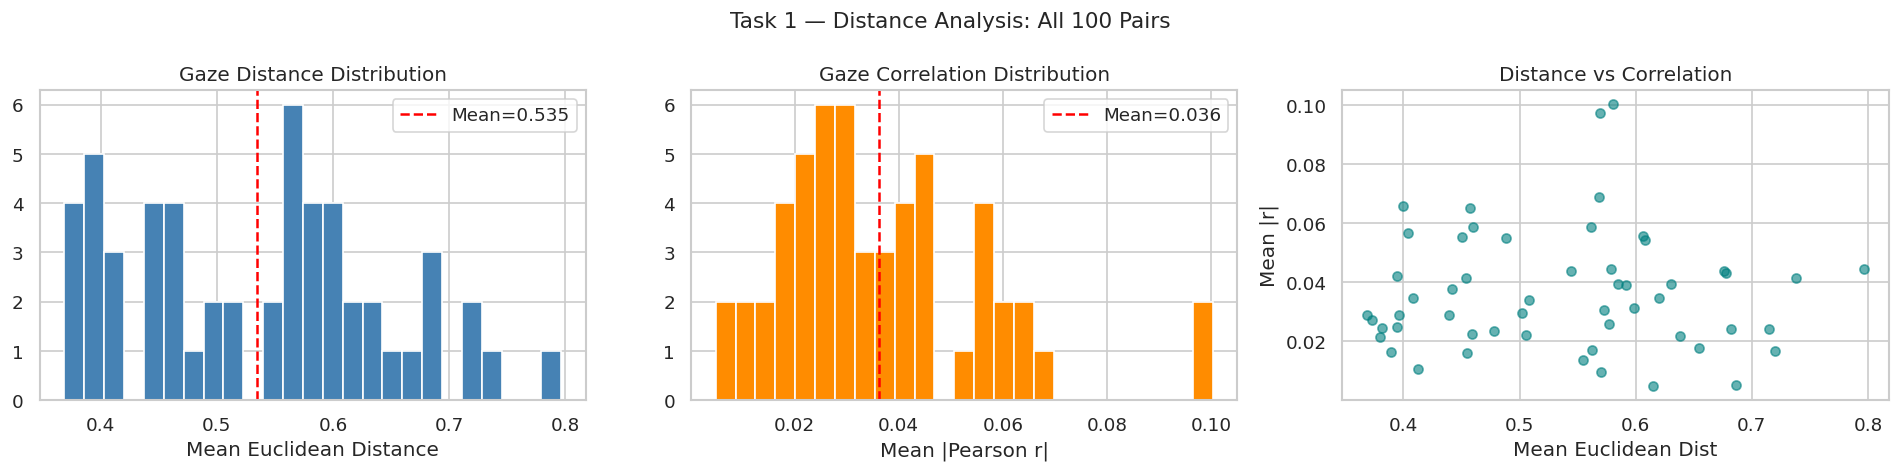

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

dist_df['mean_euclid'].hist(ax=axes[0], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(dist_df['mean_euclid'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean={dist_df['mean_euclid'].mean():.3f}")
axes[0].set_xlabel('Mean Euclidean Distance'); axes[0].set_title('Gaze Distance Distribution')
axes[0].legend()

dist_df['mean_abs_corr'].hist(ax=axes[1], bins=25, color='darkorange', edgecolor='white')
axes[1].axvline(dist_df['mean_abs_corr'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean={dist_df['mean_abs_corr'].mean():.3f}")
axes[1].set_xlabel('Mean |Pearson r|'); axes[1].set_title('Gaze Correlation Distribution')
axes[1].legend()

# Distance by relationship type
if dist_df['relationship'].nunique() > 1:
    sns.boxplot(data=dist_df, x='relationship', y='mean_euclid',
                palette='Set2', ax=axes[2])
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].set_title('Gaze Distance by Relationship Type')
    axes[2].set_xlabel('')
else:
    axes[2].scatter(dist_df['mean_euclid'], dist_df['mean_abs_corr'],
                    alpha=0.6, color='teal', s=30)
    axes[2].set_xlabel('Mean Euclidean Dist'); axes[2].set_ylabel('Mean |r|')
    axes[2].set_title('Distance vs Correlation')

fig.suptitle('Task 1 — Distance Analysis: All 100 Pairs', fontsize=13)
plt.tight_layout()
plt.show()

### 5c. 3P-V Annotation-Based Gaze Analysis
Even without `.npz` files, we can analyze gaze from the 3P-V visual behavior annotations.

In [9]:
def extract_gaze_annotations(annotations: list) -> pd.DataFrame:
    """
    Filter 3P-V annotations to gaze-related behaviors.
    Returns a DataFrame with columns: start_time, end_time, behavior, duration.
    """
    gaze_keywords = ['gaze', 'look', 'eye', 'mutual', 'stare', 'glance', 'avert']
    rows = []
    for ann in annotations:
        # Handle both flat and nested annotation formats
        behavior = ann.get('behavior', ann.get('label', ann.get('type', '')))
        if not isinstance(behavior, str):
            behavior = str(behavior)
        if any(kw in behavior.lower() for kw in gaze_keywords):
            start = ann.get('start_time', ann.get('start', 0))
            end   = ann.get('end_time',   ann.get('end',   0))
            rows.append({
                'behavior': behavior,
                'start_time': float(start) if start else 0.0,
                'end_time':   float(end)   if end   else 0.0,
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['duration'] = df['end_time'] - df['start_time']
    return df


# Aggregate gaze annotation stats across all 100 interactions
annot_stats = []
for row in catalog.itertuples():
    iid = row.interaction_id
    ac  = annot_cache.get(iid, {})
    ga  = extract_gaze_annotations(ac.get('a', []))
    gb  = extract_gaze_annotations(ac.get('b', []))

    annot_stats.append({
        'interaction_id':    iid,
        'relationship':      row.relationship,
        'n_gaze_events_a':   len(ga),
        'n_gaze_events_b':   len(gb),
        'total_gaze_dur_a':  ga['duration'].sum() if not ga.empty else 0,
        'total_gaze_dur_b':  gb['duration'].sum() if not gb.empty else 0,
        'n_mutual':          len(ga) + len(gb),  # proxy for joint gaze events
    })

annot_df = pd.DataFrame(annot_stats)
print(f"Gaze annotation events found across {len(annot_df)} interactions")
print(f"  Mean gaze events per participant A: {annot_df['n_gaze_events_a'].mean():.2f}")
print(f"  Mean gaze events per participant B: {annot_df['n_gaze_events_b'].mean():.2f}")
annot_df.head()

Gaze annotation events found across 100 interactions
  Mean gaze events per participant A: 0.00
  Mean gaze events per participant B: 0.00


,interaction_id,relationship,n_gaze_events_a,n_gaze_events_b,total_gaze_dur_a,total_gaze_dur_b,n_mutual
0,V00_S1132_I00000333,unknown,0,0,0,0,0
1,V00_S1132_I00000335,unknown,0,0,0,0,0
2,V00_S1132_I00000336,unknown,0,0,0,0,0
3,V00_S1132_I00000337,unknown,0,0,0,0,0
4,V00_S1132_I00000352,unknown,0,0,0,0,0


/tmp/ipykernel_8061/18813175.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(annot_df['n_gaze_events_a'], annot_df['n_gaze_events_b'])


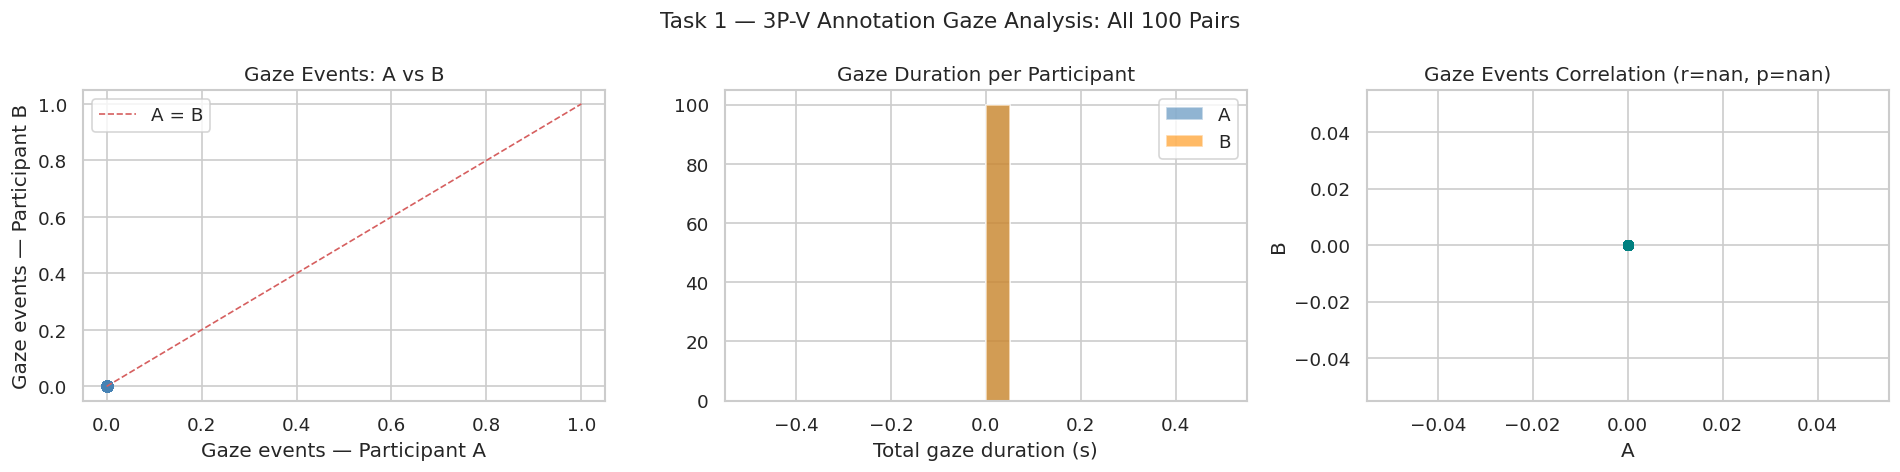

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gaze event counts A vs B
axes[0].scatter(annot_df['n_gaze_events_a'], annot_df['n_gaze_events_b'],
                alpha=0.5, color='steelblue', s=40)
mx = max(annot_df['n_gaze_events_a'].max(), annot_df['n_gaze_events_b'].max()) + 1
axes[0].plot([0, mx], [0, mx], 'r--', lw=1, label='A = B')
axes[0].set_xlabel('Gaze events — Participant A')
axes[0].set_ylabel('Gaze events — Participant B')
axes[0].set_title('Gaze Events: A vs B')
axes[0].legend()

# Gaze duration distribution
annot_df['total_gaze_dur_a'].hist(ax=axes[1], bins=20, alpha=0.6,
                                   color='steelblue', label='A', edgecolor='white')
annot_df['total_gaze_dur_b'].hist(ax=axes[1], bins=20, alpha=0.6,
                                   color='darkorange', label='B', edgecolor='white')
axes[1].set_xlabel('Total gaze duration (s)')
axes[1].set_title('Gaze Duration per Participant')
axes[1].legend()

# By relationship type
if annot_df['relationship'].nunique() > 1:
    annot_df['avg_gaze'] = (annot_df['n_gaze_events_a'] + annot_df['n_gaze_events_b']) / 2
    sns.boxplot(data=annot_df, x='relationship', y='avg_gaze',
                palette='Set2', ax=axes[2])
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].set_title('Avg Gaze Events by Relationship')
    axes[2].set_xlabel('')
else:
    r, p = pearsonr(annot_df['n_gaze_events_a'], annot_df['n_gaze_events_b'])
    axes[2].scatter(annot_df['n_gaze_events_a'], annot_df['n_gaze_events_b'],
                    alpha=0.5, color='teal', s=30)
    axes[2].set_title(f'Gaze Events Correlation (r={r:.3f}, p={p:.3f})')
    axes[2].set_xlabel('A'); axes[2].set_ylabel('B')

fig.suptitle('Task 1 — 3P-V Annotation Gaze Analysis: All 100 Pairs', fontsize=13)
plt.tight_layout()
plt.show()

---
## TASK 2 — Gaze Synchrony via Cosine Distance

### 6a. Frame-Level Cosine Distance — All Pairs

In [11]:
def frame_cosine_distance(ga, gb):
    T   = min(len(ga), len(gb))
    a_n = normalize(ga[:T], norm='l2')
    b_n = normalize(gb[:T], norm='l2')
    return 1.0 - np.einsum('td,td->t', a_n, b_n)


def cross_lagged_synchrony(ga, gb, max_lag_s=2.0):
    """Cross-correlate PC1 of each participant's gaze as 1D proxy signal."""
    T    = min(len(ga), len(gb))
    pca  = PCA(n_components=1)
    p1_a = pca.fit_transform(ga[:T]).ravel(); p1_a -= p1_a.mean()
    p1_b = pca.fit_transform(gb[:T]).ravel(); p1_b -= p1_b.mean()
    xcorr   = correlate(p1_a, p1_b, mode='full')
    max_lag = int(max_lag_s * FPS)
    mid     = len(xcorr) // 2
    xc      = xcorr[mid - max_lag: mid + max_lag + 1]
    lags    = np.arange(-max_lag, max_lag + 1) / FPS
    peak    = lags[np.argmax(xc)]
    return lags, xc, peak


sync_results = []

for row in tqdm(gaze_catalog.itertuples(), total=len(gaze_catalog),
                desc='Computing synchrony'):
    iid = row.interaction_id
    ga  = gaze_cache[iid]['a']
    gb  = gaze_cache[iid]['b']
    if ga is None or gb is None:
        continue

    cos_d          = frame_cosine_distance(ga, gb)
    lags, xc, peak = cross_lagged_synchrony(ga, gb)
    direction      = 'A_leads' if peak < -0.05 else ('B_leads' if peak > 0.05 else 'simultaneous')

    sync_results.append({
        'interaction_id':   iid,
        'relationship':     row.relationship,
        'duration_s':       row.duration_s,
        'mean_cosine_dist': float(np.nanmean(cos_d)),
        'mean_cosine_sim':  float(1 - np.nanmean(cos_d)),
        'std_cosine_dist':  float(np.nanstd(cos_d)),
        'pct_high_sync':    float(np.mean(cos_d < 0.3) * 100),
        'peak_lag_s':       float(peak),
        'lag_direction':    direction,
    })

sync_df = pd.DataFrame(sync_results)
print(f"Synchrony results for {len(sync_df)} pairs")
sync_df.describe()

Computing synchrony:   0%|          | 0/54 [00:00<?, ?it/s]

Synchrony results for 54 pairs


,duration_s,mean_cosine_dist,mean_cosine_sim,std_cosine_dist,pct_high_sync,peak_lag_s
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,292.703704,0.793091,0.206909,0.651096,37.366407,0.234568
std,118.415423,0.217483,0.217483,0.100917,13.349966,1.226472
min,122.000000,0.363841,-0.257447,0.440168,13.765432,-2.000000
25%,206.000000,0.665558,0.093168,0.590539,26.691145,-0.800000
50%,262.000000,0.775130,0.224870,0.677011,36.602600,0.350000
75%,383.500000,0.906832,0.334442,0.727990,46.396060,1.308333
max,606.000000,1.257447,0.636159,0.799311,64.646465,2.000000


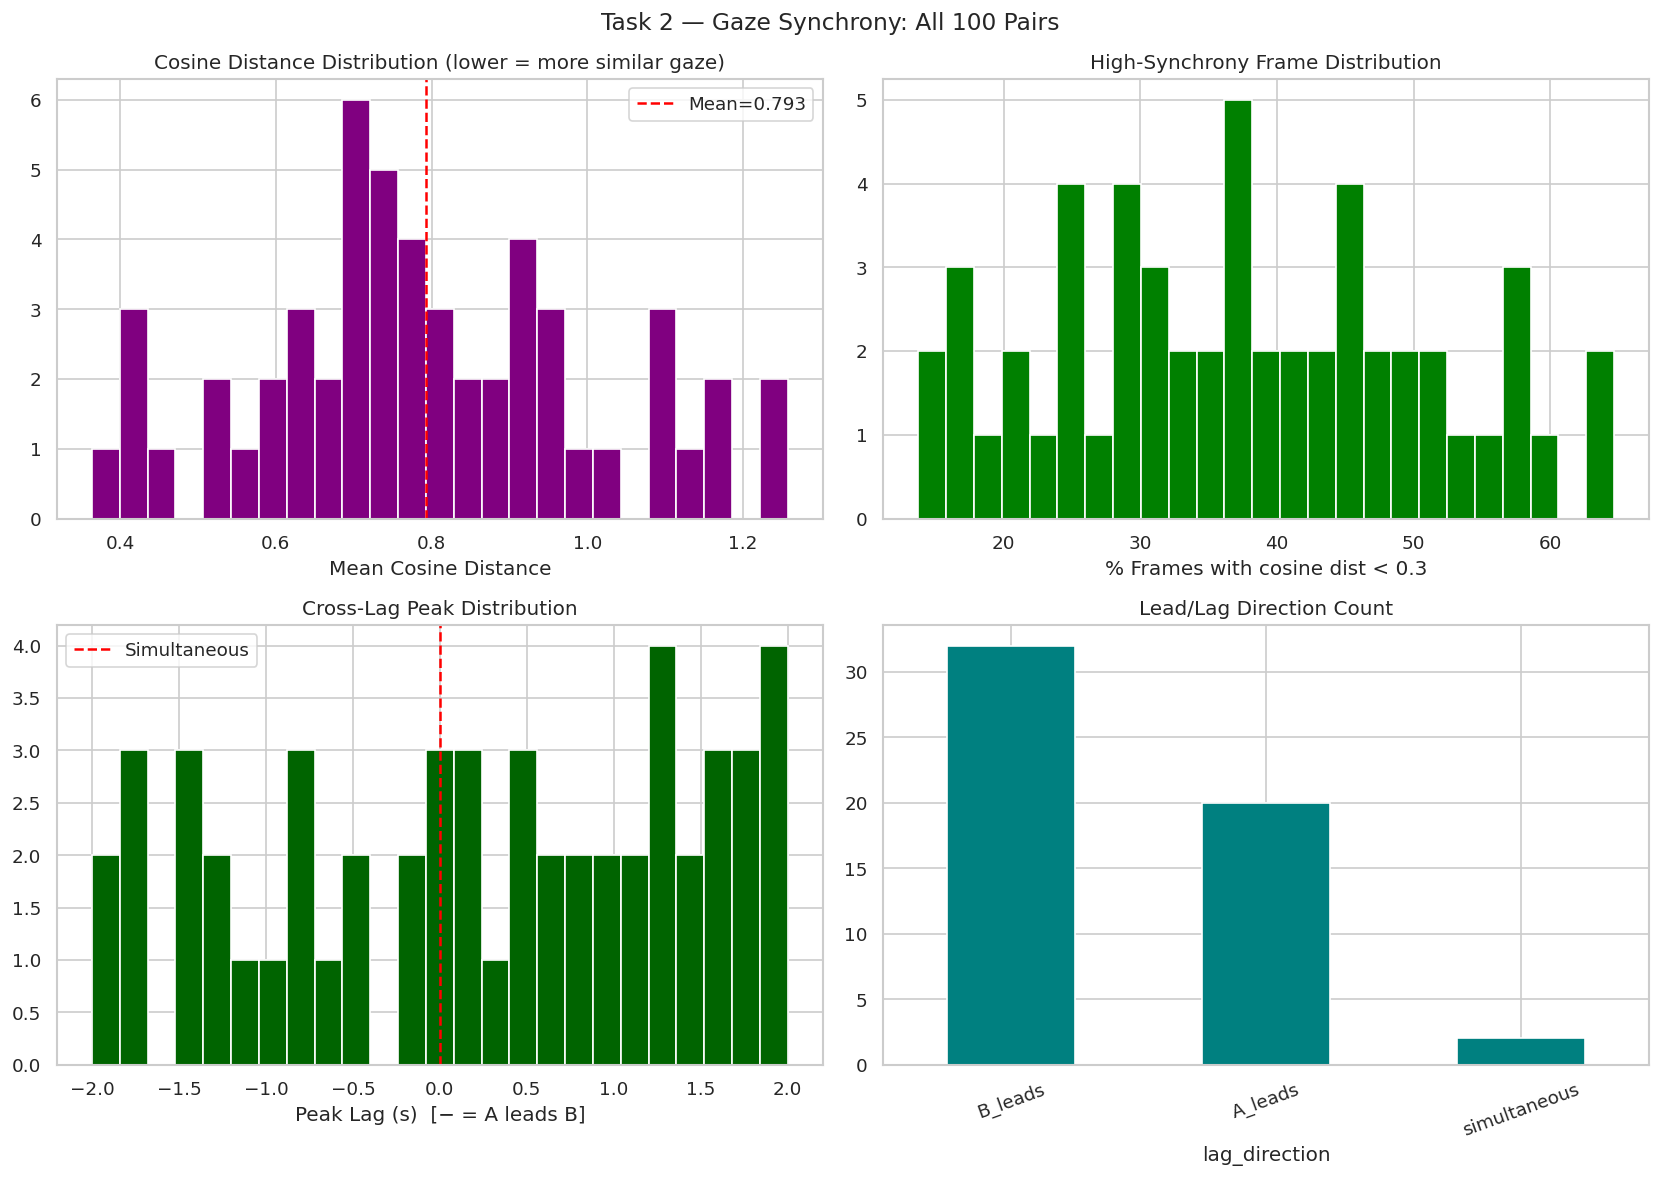

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean cosine distance distribution
sync_df['mean_cosine_dist'].hist(ax=axes[0,0], bins=25, color='purple', edgecolor='white')
axes[0,0].axvline(sync_df['mean_cosine_dist'].mean(), color='red', ls='--', lw=1.5,
                   label=f"Mean={sync_df['mean_cosine_dist'].mean():.3f}")
axes[0,0].set_xlabel('Mean Cosine Distance')
axes[0,0].set_title('Cosine Distance Distribution (lower = more similar gaze)')
axes[0,0].legend()

# % high sync frames
sync_df['pct_high_sync'].hist(ax=axes[0,1], bins=25, color='green', edgecolor='white')
axes[0,1].set_xlabel('% Frames with cosine dist < 0.3')
axes[0,1].set_title('High-Synchrony Frame Distribution')

# Peak lag distribution
sync_df['peak_lag_s'].hist(ax=axes[1,0], bins=25, color='darkgreen', edgecolor='white')
axes[1,0].axvline(0, color='red', ls='--', lw=1.5, label='Simultaneous')
axes[1,0].set_xlabel('Peak Lag (s)  [− = A leads B]')
axes[1,0].set_title('Cross-Lag Peak Distribution')
axes[1,0].legend()

# Synchrony by relationship type
if sync_df['relationship'].nunique() > 1:
    sns.boxplot(data=sync_df, x='relationship', y='mean_cosine_sim',
                palette='Set2', ax=axes[1,1])
    axes[1,1].tick_params(axis='x', rotation=30)
    axes[1,1].set_title('Gaze Similarity by Relationship Type\n(higher = more similar)')
    axes[1,1].set_xlabel('')
else:
    lag_counts = sync_df['lag_direction'].value_counts()
    lag_counts.plot(kind='bar', ax=axes[1,1], color='teal', edgecolor='white')
    axes[1,1].set_title('Lead/Lag Direction Count')
    axes[1,1].tick_params(axis='x', rotation=20)

fig.suptitle('Task 2 — Gaze Synchrony: All 100 Pairs', fontsize=14)
plt.tight_layout()
plt.show()

### 6b. Cosine Distance Over Time — Sample of 4 Interactions

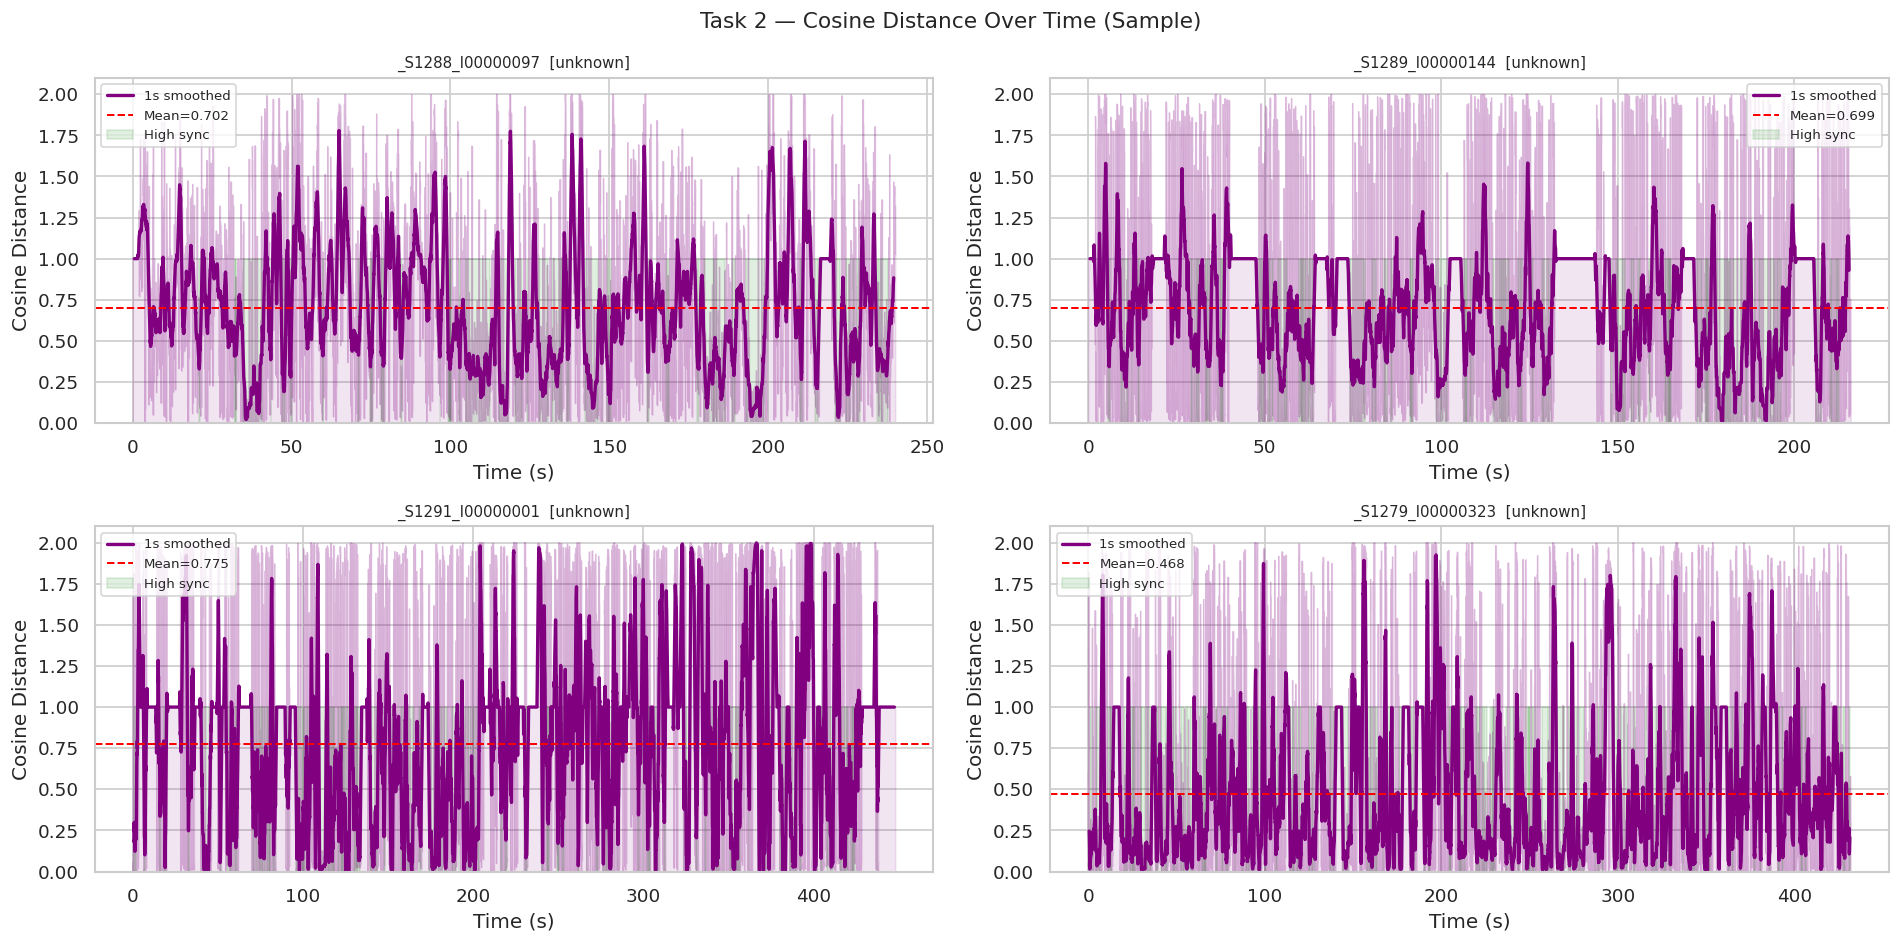

In [13]:
if len(gaze_catalog) >= 4:
    sample4 = gaze_catalog.sample(4, random_state=7)
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for ax, row in zip(axes, sample4.itertuples()):
        iid  = row.interaction_id
        ga   = gaze_cache[iid]['a']
        gb   = gaze_cache[iid]['b']
        T    = min(len(ga), len(gb))
        t    = np.arange(T) / FPS
        cd   = frame_cosine_distance(ga, gb)
        sm   = pd.Series(cd).rolling(30, center=True).mean().values
        valid_sm = sm[~np.isnan(sm)]

        ax.fill_between(t, cd, alpha=0.1, color='purple')
        ax.plot(t, cd, alpha=0.2, lw=0.7, color='purple')
        ax.plot(t, sm, lw=2, color='purple', label='1s smoothed')
        ax.axhline(np.nanmean(cd), color='red', ls='--', lw=1.2,
                   label=f'Mean={np.nanmean(cd):.3f}')
        ax.fill_between(t, 0, 1,
                        where=sm < np.nanpercentile(valid_sm, 25),
                        alpha=0.12, color='green', label='High sync')
        ax.set_ylim(0, min(2.1, np.nanpercentile(cd, 99) * 1.3))
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Cosine Distance')
        ax.set_title(f"{iid[-16:]}  [{row.relationship}]", fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle('Task 2 — Cosine Distance Over Time (Sample)', fontsize=13)
    plt.tight_layout()
    plt.show()

### 6c. Familiar vs Stranger Synchrony Comparison
Test whether familiar pairs show higher gaze synchrony than strangers.

In [14]:
if sync_df['relationship'].nunique() > 1:
    familiar_mask = sync_df['relationship'].str.lower().str.contains('familiar|friend|family|colleague')
    familiar  = sync_df[familiar_mask]['mean_cosine_sim'].dropna()
    strangers = sync_df[~familiar_mask]['mean_cosine_sim'].dropna()

    if len(familiar) > 1 and len(strangers) > 1:
        t_stat, p_val = ttest_ind(familiar, strangers)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(familiar,  bins=15, alpha=0.6, color='steelblue',
                label=f'Familiar (n={len(familiar)}, mean={familiar.mean():.3f})', edgecolor='white')
        ax.hist(strangers, bins=15, alpha=0.6, color='darkorange',
                label=f'Strangers (n={len(strangers)}, mean={strangers.mean():.3f})', edgecolor='white')
        ax.set_xlabel('Mean Cosine Similarity')
        ax.set_title(f'Gaze Synchrony: Familiar vs Strangers\nt={t_stat:.3f}, p={p_val:.4f}'
                     f'  {"(significant)" if p_val < 0.05 else "(not significant)"}')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough data in both groups for comparison.")
else:
    print("Only one relationship type in dataset — skipping familiar vs stranger comparison.")
    print("Relationship values found:", sync_df['relationship'].unique())

Only one relationship type in dataset — skipping familiar vs stranger comparison.
Relationship values found: ['unknown']


### 6d. Synchrony Heatmap — All 100 Pairs Ranked

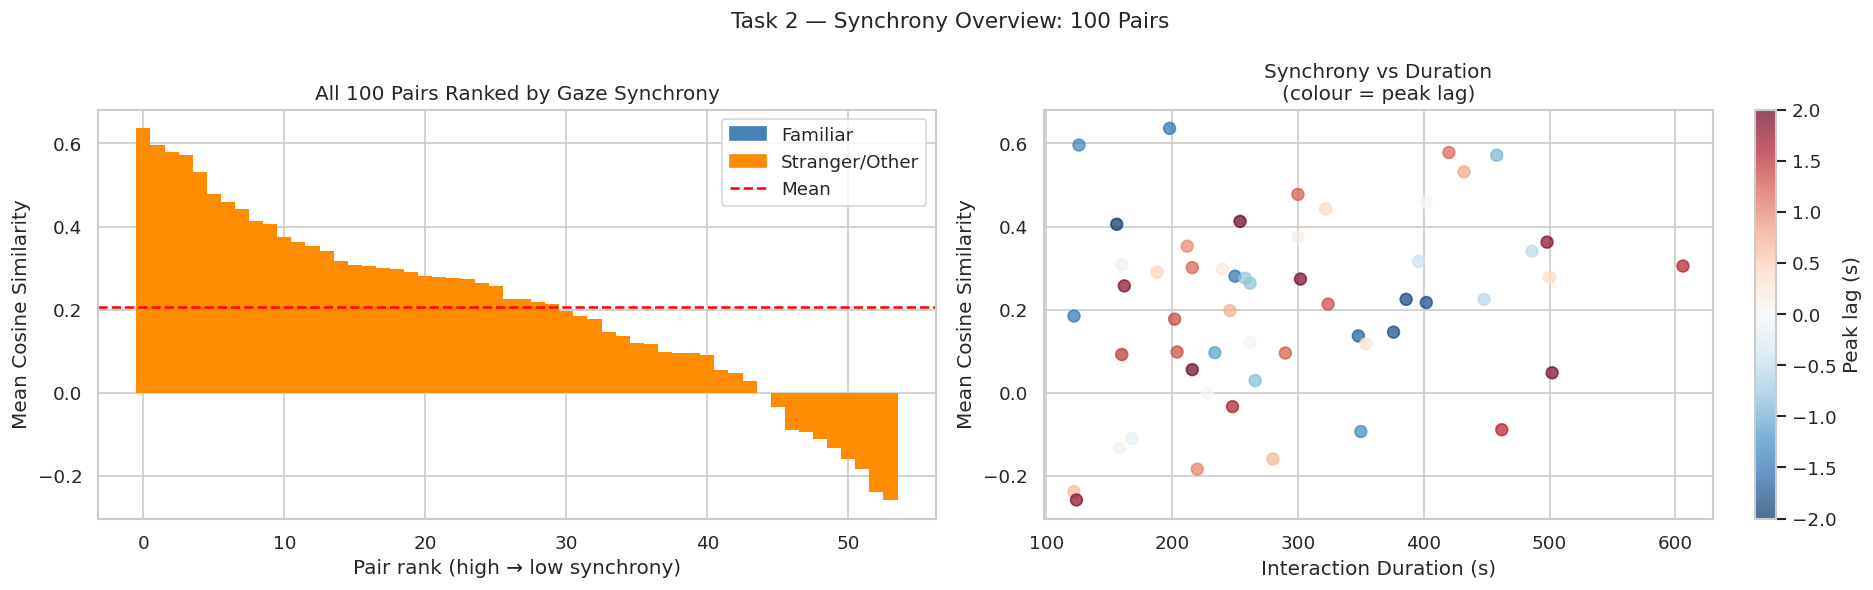

In [15]:
if not sync_df.empty:
    sorted_sync = sync_df.sort_values('mean_cosine_sim', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Ranked bar chart
    colors = ['steelblue' if rel.lower() in ['familiar','friend','family','colleague']
              else 'darkorange'
              for rel in sorted_sync['relationship']]
    axes[0].bar(range(len(sorted_sync)), sorted_sync['mean_cosine_sim'],
                color=colors, edgecolor='none', width=1.0)
    axes[0].axhline(sorted_sync['mean_cosine_sim'].mean(), color='red',
                    ls='--', lw=1.5, label='Mean')
    axes[0].set_xlabel('Pair rank (high → low synchrony)')
    axes[0].set_ylabel('Mean Cosine Similarity')
    axes[0].set_title('All 100 Pairs Ranked by Gaze Synchrony')
    from matplotlib.patches import Patch
    axes[0].legend(handles=[
        Patch(color='steelblue', label='Familiar'),
        Patch(color='darkorange', label='Stranger/Other'),
        plt.Line2D([0],[0], color='red', ls='--', label='Mean')
    ])

    # Scatter: synchrony vs duration
    sc = axes[1].scatter(sorted_sync['duration_s'],
                          sorted_sync['mean_cosine_sim'],
                          c=sorted_sync['peak_lag_s'], cmap='RdBu_r',
                          s=50, alpha=0.7, vmin=-2, vmax=2)
    plt.colorbar(sc, ax=axes[1], label='Peak lag (s)')
    axes[1].set_xlabel('Interaction Duration (s)')
    axes[1].set_ylabel('Mean Cosine Similarity')
    axes[1].set_title('Synchrony vs Duration\n(colour = peak lag)')

    fig.suptitle('Task 2 — Synchrony Overview: 100 Pairs', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 7. Export Results

In [16]:
catalog.to_csv('catalog_100_interactions.csv', index=False)
dist_df.to_csv('gaze_distance_results.csv', index=False)
sync_df.to_csv('gaze_synchrony_results.csv', index=False)
annot_df.to_csv('gaze_annotation_results.csv', index=False)

print("Saved:")
print("  catalog_100_interactions.csv    — full metadata for all 100 pairs")
print("  gaze_distance_results.csv       — Task 1: Euclidean dist + Pearson r")
print("  gaze_synchrony_results.csv      — Task 2: cosine dist, synchrony, lag")
print("  gaze_annotation_results.csv     — 3P-V annotation-based gaze stats")

Saved:
  catalog_100_interactions.csv    — full metadata for all 100 pairs
  gaze_distance_results.csv       — Task 1: Euclidean dist + Pearson r
  gaze_synchrony_results.csv      — Task 2: cosine dist, synchrony, lag
  gaze_annotation_results.csv     — 3P-V annotation-based gaze stats
